# GAT activation patching — clean vs perturbed
Compares node features and edge attention weights between clean and augmented inputs.

In [1]:
import os, sys, math, random
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from fractions import Fraction
import torchaudio.functional as F_audio
from collections import defaultdict

notebook_dir = os.getcwd()
if notebook_dir not in sys.path:
    sys.path.insert(0, notebook_dir)

from argparse import Namespace
from phoneme_GAT.modules import Phoneme_GAT_lit, Phoneme_GAT
from loader import _crop_policy, TARGET_SR, _label_to_int, _make_balanced_indices
from datasets import load_dataset, Audio as HFAudio

def load_hf_token(path="secret.txt"):
    if os.path.exists(path):
        with open(path) as f: return f.read().strip()
    return None

HF_TOKEN = load_hf_token()
DEVICE   = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/venv/lib/python3.10/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


Device: cuda


/lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/loader.py:18: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("sox_io")


In [3]:
import torch

# Monkey-patch torch.load to default to weights_only=False (Torch 2.6+ defaults to True)
_orig_torch_load = torch.load

def _torch_load_no_weights_only(*args, **kwargs):
    kwargs.setdefault("weights_only", False)
    return _orig_torch_load(*args, **kwargs)

torch.load = _torch_load_no_weights_only
print("✅ Patched torch.load to default weights_only=False for this kernel session.")


✅ Patched torch.load to default weights_only=False for this kernel session.


In [4]:
# ── Load model ────────────────────────────────────────────────────────────
cfg = Namespace(PhonemeGAT=Namespace(
    backbone="wavlm", use_raw=False, use_GAT=True,
    n_edges=10, use_aug=False, use_pool=True, use_clip=True,
))

CKPT = "robust_goat.ckpt"   # ← swap to compare models
lit  = Phoneme_GAT_lit.load_from_checkpoint(CKPT, cfg=cfg)
model = lit.model.to(DEVICE).eval()
print(f"Loaded {CKPT}")

Now, load vocab json files from /lambda/nfs/algovirginia/workspace/DeepfakeDetectionRenewed/vocab_phoneme Please make sure the vocab files are correct
Load WavLM model!!!!!!!


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Some weights of WavLMForCTC were not initialized from the model checkpoint at microsoft/wavlm-base and are newly initialized: ['encoder.pos_conv_embed.conv.parametrizations.weight.original1', 'encoder.pos_conv_embed.conv.parametrizations.weight.original0', 'lm_head.weight', 'lm_head.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


torch.Size([687, 768])
Loaded robust_goat.ckpt


## 1. Load a fixed batch of samples

In [5]:
DATASET_NAME = "Bisher/ASVspoof_2019_LA"
CACHE_DIR    = "./data/asvspoof_2019_la"
N_SAMPLES    = 16   # fixed batch size for all comparisons

hf_val = load_dataset(DATASET_NAME, split="validation",
                       cache_dir=CACHE_DIR,
                       token=HF_TOKEN if HF_TOKEN else None)
hf_val = hf_val.cast_column("audio", HFAudio(sampling_rate=TARGET_SR))

# Pick N_SAMPLES balanced (half bonafide, half spoof)
label_key = next((k for k in hf_val[0].keys()
                   if "label" in k.lower() or k.lower() == "key"), "label")
labels = [_label_to_int(hf_val[i][label_key]) for i in range(len(hf_val))]
idx    = _make_balanced_indices(labels, seed=0, limit=N_SAMPLES)

wavs, ys = [], []
for i in idx:
    ex  = hf_val[i]
    wav = torch.tensor(ex["audio"]["array"], dtype=torch.float32).unsqueeze(0)
    wav = _crop_policy(wav, "eval")
    wavs.append(wav)
    ys.append(_label_to_int(ex[label_key]))

clean_batch = torch.stack(wavs).to(DEVICE)          # (N, 1, T)
labels_t    = torch.tensor(ys, device=DEVICE)
print(f"Batch: {clean_batch.shape}  labels: {labels_t.tolist()}")

Batch: torch.Size([16, 1, 48000])  labels: [1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1]


## 2. Augmentation functions

In [6]:
def _match_len(x, n):
    if x.shape[-1] < n:
        x = torch.nn.functional.pad(x, (0, n - x.shape[-1]))
    return x[..., :n]

def aug_noise(wav, snr_db=16):
    sig_power   = wav.pow(2).mean()
    noise       = torch.randn_like(wav)
    noise_power = noise.pow(2).mean()
    scale       = (sig_power / (noise_power * 10 ** (snr_db / 10))).sqrt()
    return wav + scale * noise

def aug_pitch_up(wav, semitones=3):
    factor = 2 ** (semitones / 12)
    frac   = Fraction(factor).limit_denominator(20)
    return _match_len(F_audio.resample(wav, frac.numerator, frac.denominator), wav.shape[-1])

def aug_reverb(wav, t60=0.5, room_scale=0.5):
    T       = wav.shape[-1]
    rir_len = min(int(t60 * TARGET_SR), 1600)
    t       = torch.linspace(0, t60, rir_len, device=wav.device)
    decay   = torch.exp(-6.9 * t / t60)
    rir     = torch.randn(rir_len, device=wav.device) * decay
    for d_ms in [15, 30, 50]:
        d = int(d_ms * 1e-3 * TARGET_SR * room_scale)
        if d < rir_len: rir[d] += 0.4 * room_scale * decay[d]
    rir   = rir / (rir.abs().max() + 1e-8)
    n_fft = 2 ** math.ceil(math.log2(T + rir_len - 1))
    out   = torch.fft.irfft(
        torch.fft.rfft(wav, n=n_fft) * torch.fft.rfft(rir, n=n_fft), n=n_fft)
    return out[..., :T]

# ── Choose active augmentation ────────────────────────────────────────────
ACTIVE_AUG    = "noise"    # ← "noise" | "pitch_up" | "reverb"
AUG_PARAMS    = {
    "noise":    {"snr_db": 16},
    "pitch_up": {"semitones": 3},
    "reverb":   {"t60": 0.5, "room_scale": 0.5},
}
AUG_FNS = {
    "noise":    aug_noise,
    "pitch_up": aug_pitch_up,
    "reverb":   aug_reverb,
}

aug_fn      = AUG_FNS[ACTIVE_AUG]
aug_params  = AUG_PARAMS[ACTIVE_AUG]
perturbed_batch = aug_fn(clean_batch.clone(), **aug_params)
print(f"Augmentation: {ACTIVE_AUG} {aug_params}")
print(f"Perturbed batch shape: {perturbed_batch.shape}")

Augmentation: noise {'snr_db': 16}
Perturbed batch shape: torch.Size([16, 1, 48000])


## 3. Hook GAT activations

In [9]:
# ── Storage for hooked activations ───────────────────────────────────────
_hooks   = []
_buffers = defaultdict(list)

def _make_node_hook(name):
    """Hook that captures the node feature output of each GAT layer."""
    def hook(module, input, output):
        # GAT layers return (node_features, edge_index) tuple
        node_feat = output[0] if isinstance(output, tuple) else output
        _buffers[name].append(node_feat.detach().cpu())
    return hook

def _make_attn_hook(name):
    """
    Hook that captures attention coefficients.
    In the GAT implementation, attention weights are computed inside
    GATLayer as 'attention_coefficients' before softmax aggregation.
    We capture the pre-softmax scores from the linear attention layer.
    """
    def hook(module, input, output):
        _buffers[name].append(output.detach().cpu())
    return hook

def register_hooks(gat_module):
    for i, layer in enumerate(gat_module.gat_net):
        # Node output after each GAT layer
        h = layer.register_forward_hook(_make_node_hook(f"gat_layer_{i}_nodes"))
        _hooks.append(h)
        
        # Capture attention weights via full-layer hook
        # The layer computes attention as softmax(src_scores + tgt_scores)
        # We extract it from the layer's internal computation by hooking
        # the layer itself and re-deriving attention from its parameters
        def _make_full_layer_hook(name, layer_ref):
            def hook(module, input, output):
                # input[0] is (node_features, edge_index) tuple
                node_feat, edge_idx = input[0]
                if edge_idx.numel() == 0:
                    return
                try:
                    # Re-compute attention scores from stored parameters
                    # src_score: each source node's contribution
                    src_scores = (node_feat @ module.scoring_fn_source).squeeze(-1)  # (N,)
                    tgt_scores = (node_feat @ module.scoring_fn_target).squeeze(-1)  # (N,)
                    # Edge-level attention = src[i] + tgt[j] for each edge (i,j)
                    attn_raw = src_scores[edge_idx[0]] + tgt_scores[edge_idx[1]]  # (E,)
                    attn_raw = torch.nn.functional.leaky_relu(attn_raw, negative_slope=0.2)
                    _buffers[name].append(attn_raw.detach().cpu())
                except Exception as e:
                    pass  # skip if shape mismatch
            return hook
        
        h2 = layer.register_forward_hook(_make_full_layer_hook(f"gat_layer_{i}_attn", layer))
        _hooks.append(h2)

def remove_hooks():
    for h in _hooks: h.remove()
    _hooks.clear()

def clear_buffers():
    _buffers.clear()

print("Hook utilities ready.")
print(f"GAT layers: {len(list(model.GAT.gat_net))}")
for i, layer in enumerate(model.GAT.gat_net):
    print(f"  Layer {i}: {type(layer).__name__}  "
          f"has scoring_fn_source={hasattr(layer,'scoring_fn_source')}  "
          f"has scoring_fn_target={hasattr(layer,'scoring_fn_target')}")

Hook utilities ready.
GAT layers: 3
  Layer 0: GATLayer  has scoring_fn_source=True  has scoring_fn_target=True
  Layer 1: GATLayer  has scoring_fn_source=True  has scoring_fn_target=True
  Layer 2: GATLayer  has scoring_fn_source=True  has scoring_fn_target=True


In [10]:
def run_forward(batch):
    """Run a batch through the model and collect hooked activations."""
    B = batch.shape[0]
    x = batch[:, 0, :] if batch.ndim == 3 else batch
    num_frames = torch.full((B,), TARGET_SR // 320 - 1, device=DEVICE)

    clear_buffers()
    register_hooks(model.GAT)

    with torch.no_grad():
        out = model(x, num_frames, use_aug=False, stage="eval")

    remove_hooks()

    node_feats = {k: v[0] for k, v in _buffers.items() if "nodes" in k}
    attn       = {k: v[0] for k, v in _buffers.items() if "attn" in k and "nodes" not in k}

    return out, node_feats, attn

print("Running clean batch...")
out_clean, nodes_clean, attn_clean = run_forward(clean_batch)

print("Running perturbed batch...")
out_perturbed, nodes_perturbed, attn_perturbed = run_forward(perturbed_batch)

print("\nNode feature keys:", list(nodes_clean.keys()))
print("Attn keys:        ", list(attn_clean.keys()))
for k, v in nodes_clean.items():
    print(f"  {k}: {v.shape}")
for k, v in attn_clean.items():
    print(f"  {k}: {v.shape}")

Running clean batch...
Running perturbed batch...

Node feature keys: ['gat_layer_0_nodes', 'gat_layer_1_nodes', 'gat_layer_2_nodes']
Attn keys:         []
  gat_layer_0_nodes: torch.Size([140, 768])
  gat_layer_1_nodes: torch.Size([140, 768])
  gat_layer_2_nodes: torch.Size([140, 768])


## 4. Compute activation differences

In [11]:
def l2_norm(x):
    return torch.norm(x, p=2, dim=-1)   # (N,)

def cosine_sim(a, b):
    a = F.normalize(a, dim=-1)
    b = F.normalize(b, dim=-1)
    return (a * b).sum(dim=-1)          # (N,)  — 1=identical, -1=opposite

results = {}

for layer_name in nodes_clean:
    c = nodes_clean[layer_name].float()       # (total_phonemes, 768)
    p = nodes_perturbed[layer_name].float()

    # Align sizes (phoneme count can differ after augmentation)
    n = min(c.shape[0], p.shape[0])
    c, p = c[:n], p[:n]

    diff      = p - c
    l2        = l2_norm(diff)             # per-phoneme L2 of change
    cos       = cosine_sim(c, p)          # per-phoneme cosine similarity

    results[layer_name] = {
        "l2_mean":  l2.mean().item(),
        "l2_std":   l2.std().item(),
        "l2_per_node": l2.numpy(),
        "cos_mean": cos.mean().item(),
        "cos_std":  cos.std().item(),
        "cos_per_node": cos.numpy(),
        "n_phonemes": n,
    }

print(f"{'Layer':30s}  {'L2 mean':>9}  {'L2 std':>9}  {'Cos sim':>9}")
print("-" * 65)
for name, r in results.items():
    print(f"{name:30s}  {r['l2_mean']:9.4f}  {r['l2_std']:9.4f}  {r['cos_mean']:9.4f}")

Layer                             L2 mean     L2 std    Cos sim
-----------------------------------------------------------------
gat_layer_0_nodes                 15.1372     3.1481     0.2212
gat_layer_1_nodes                 18.7727     5.6079     0.3563
gat_layer_2_nodes                 32.2299    11.9699     0.4174


## 5. Visualize

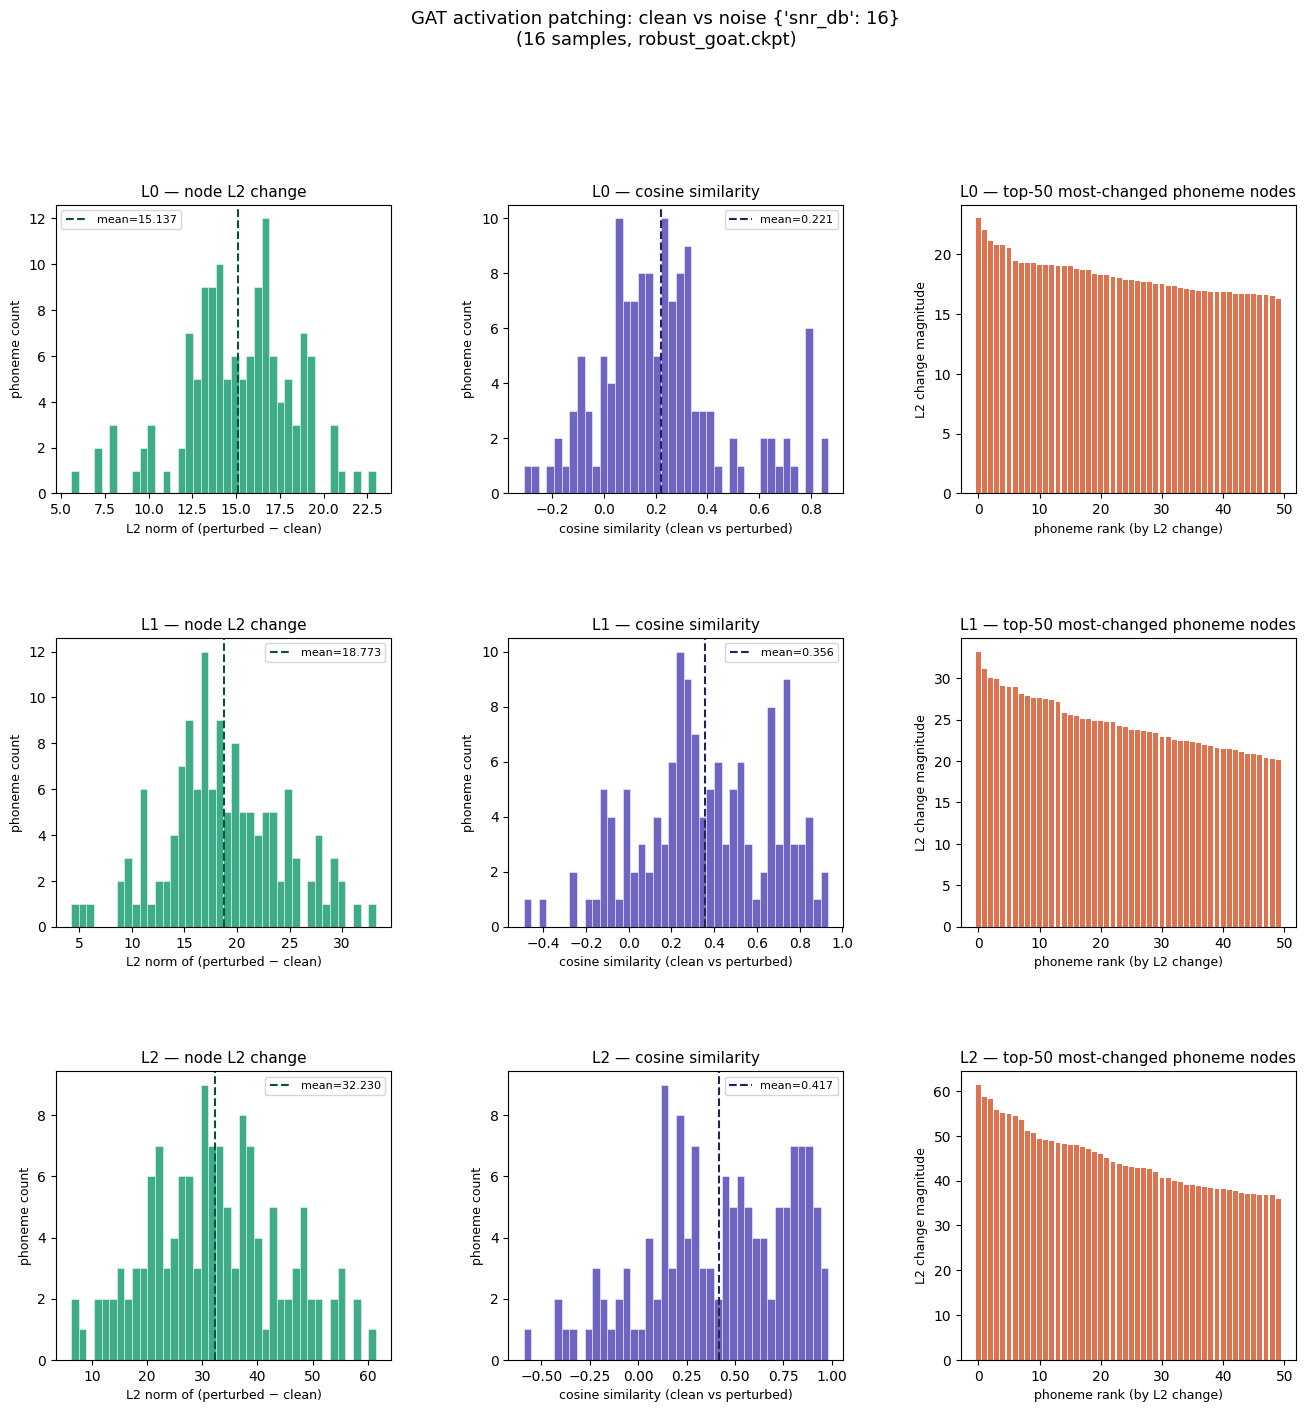

Saved activation_patching_noise.png


In [12]:
layer_names  = list(results.keys())
n_layers     = len(layer_names)
short_names  = [n.replace("gat_layer_","L").replace("_nodes","") for n in layer_names]

fig = plt.figure(figsize=(16, 5 * n_layers))
gs  = gridspec.GridSpec(n_layers, 3, figure=fig, hspace=0.5, wspace=0.35)

for row, (name, sname) in enumerate(zip(layer_names, short_names)):
    r = results[name]
    l2  = r["l2_per_node"]
    cos = r["cos_per_node"]
    n   = r["n_phonemes"]

    # ── Col 0: L2 histogram ──────────────────────────────────────────────
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.hist(l2, bins=40, color="#1D9E75", alpha=0.85, edgecolor="white", linewidth=0.4)
    ax0.axvline(l2.mean(), color="#085041", linewidth=1.5, linestyle="--",
                label=f"mean={l2.mean():.3f}")
    ax0.set_title(f"{sname} — node L2 change", fontsize=11)
    ax0.set_xlabel("L2 norm of (perturbed − clean)", fontsize=9)
    ax0.set_ylabel("phoneme count", fontsize=9)
    ax0.legend(fontsize=8)

    # ── Col 1: Cosine similarity histogram ───────────────────────────────
    ax1 = fig.add_subplot(gs[row, 1])
    ax1.hist(cos, bins=40, color="#534AB7", alpha=0.85, edgecolor="white", linewidth=0.4)
    ax1.axvline(cos.mean(), color="#26215C", linewidth=1.5, linestyle="--",
                label=f"mean={cos.mean():.3f}")
    ax1.set_title(f"{sname} — cosine similarity", fontsize=11)
    ax1.set_xlabel("cosine similarity (clean vs perturbed)", fontsize=9)
    ax1.set_ylabel("phoneme count", fontsize=9)
    ax1.legend(fontsize=8)

    # ── Col 2: Per-phoneme L2 sorted — shows which nodes change most ─────
    ax2 = fig.add_subplot(gs[row, 2])
    sorted_l2 = np.sort(l2)[::-1]
    ax2.bar(range(min(50, n)), sorted_l2[:50],
            color="#D85A30", alpha=0.85, width=0.8)
    ax2.set_title(f"{sname} — top-50 most-changed phoneme nodes", fontsize=11)
    ax2.set_xlabel("phoneme rank (by L2 change)", fontsize=9)
    ax2.set_ylabel("L2 change magnitude", fontsize=9)

fig.suptitle(
    f"GAT activation patching: clean vs {ACTIVE_AUG} {aug_params}\n"
    f"({N_SAMPLES} samples, robust_goat.ckpt)",
    fontsize=13, y=1.01
)
plt.savefig(f"activation_patching_{ACTIVE_AUG}.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved activation_patching_{ACTIVE_AUG}.png")

## 6. Layer-wise summary — how much does each GAT layer respond to the augmentation?

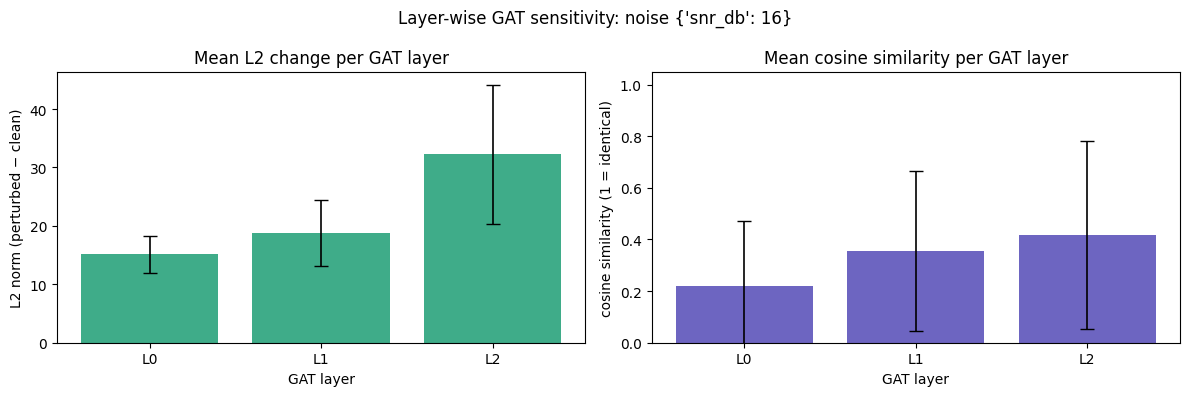

In [13]:
fig2, (ax_l2, ax_cos) = plt.subplots(1, 2, figsize=(12, 4))

l2_means  = [results[n]["l2_mean"]  for n in layer_names]
cos_means = [results[n]["cos_mean"] for n in layer_names]
l2_stds   = [results[n]["l2_std"]   for n in layer_names]
cos_stds  = [results[n]["cos_std"]  for n in layer_names]

x = np.arange(n_layers)
ax_l2.bar(x, l2_means, yerr=l2_stds, color="#1D9E75", alpha=0.85,
          capsize=5, error_kw={"linewidth": 1.2})
ax_l2.set_xticks(x); ax_l2.set_xticklabels(short_names)
ax_l2.set_title("Mean L2 change per GAT layer", fontsize=12)
ax_l2.set_ylabel("L2 norm (perturbed − clean)")
ax_l2.set_xlabel("GAT layer")

ax_cos.bar(x, cos_means, yerr=cos_stds, color="#534AB7", alpha=0.85,
           capsize=5, error_kw={"linewidth": 1.2})
ax_cos.set_xticks(x); ax_cos.set_xticklabels(short_names)
ax_cos.set_title("Mean cosine similarity per GAT layer", fontsize=12)
ax_cos.set_ylabel("cosine similarity (1 = identical)")
ax_cos.set_xlabel("GAT layer")
ax_cos.set_ylim(0, 1.05)

fig2.suptitle(f"Layer-wise GAT sensitivity: {ACTIVE_AUG} {aug_params}", fontsize=12)
plt.tight_layout()
plt.savefig(f"layerwise_sensitivity_{ACTIVE_AUG}.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Compare augmentations side by side
Run all three augmentations and plot mean L2 per layer together.

noise         layer L2: ['14.393', '17.957', '31.101']
pitch_up      layer L2: ['16.129', '20.431', '35.722']
reverb        layer L2: ['12.308', '14.244', '23.642']


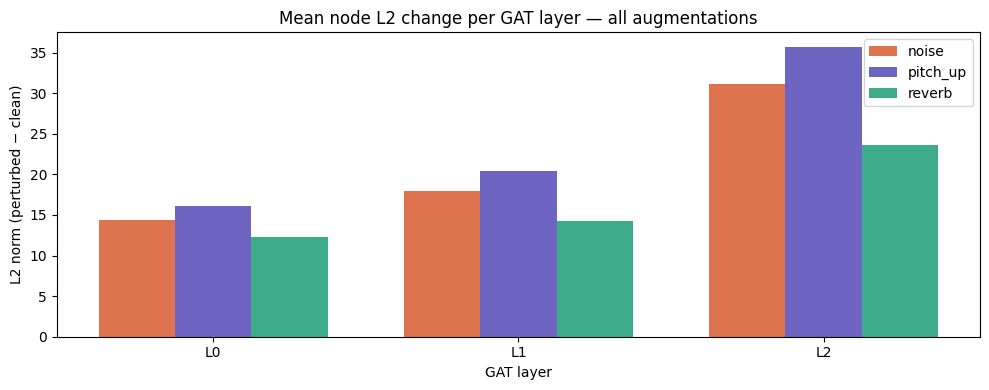

Saved layerwise_all_augs.png


In [15]:
all_aug_results = {}

for aug_name, aug_fn in AUG_FNS.items():
    params = AUG_PARAMS[aug_name]
    perturbed = aug_fn(clean_batch.clone(), **params)
    _, nodes_p, _ = run_forward(perturbed)

    layer_l2 = []
    for layer_name in nodes_clean:
        c = nodes_clean[layer_name].float()
        p = nodes_p[layer_name].float()
        n = min(c.shape[0], p.shape[0])
        l2 = l2_norm((p[:n] - c[:n])).mean().item()
        layer_l2.append(l2)

    all_aug_results[aug_name] = layer_l2
    print(f"{aug_name:12s}  layer L2: {[f'{v:.3f}' for v in layer_l2]}")

# Plot
fig3, ax = plt.subplots(figsize=(10, 4))
x       = np.arange(n_layers)
width   = 0.25
colors  = {"noise": "#D85A30", "pitch_up": "#534AB7", "reverb": "#1D9E75"}
offsets = {"noise": -width, "pitch_up": 0, "reverb": width}

for aug_name, layer_l2 in all_aug_results.items():
    ax.bar(x + offsets[aug_name], layer_l2, width=width,
           label=aug_name, color=colors[aug_name], alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(short_names)
ax.set_title("Mean node L2 change per GAT layer — all augmentations", fontsize=12)
ax.set_ylabel("L2 norm (perturbed − clean)")
ax.set_xlabel("GAT layer")
ax.legend()
plt.tight_layout()
plt.savefig("layerwise_all_augs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved layerwise_all_augs.png")